# 02. Exploratory Data Analysis

> Get a feel for the dataset before any processing: per-channel signal statistics, label timeline, gesture trial counts, and finger-flexion traces from the data glove.

The goal is to surface anomalies (bad channels, drifts, class imbalance, glove dropouts) that will inform the preprocessing and epoching choices in later notebooks. No code is exported from here — it is purely investigative.

## Setup

In [ ]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from br41n_ecog_hand_pose.data import load_ecog, FS, GESTURE_NAMES, FINGER_NAMES

plt.rcParams.update({
    'axes.grid':    True,
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'grid.alpha':   0.6,
})

## Load the recording

Load the full session once and reuse the resulting `ECoGRecording` for every plot below.

In [ ]:
#| eval: false
rec = load_ecog()
print(f'duration:    {rec.duration_s:.1f} s  ({rec.n_samples:,} samples @ {rec.fs} Hz)')
print(f'ecog shape:  {rec.ecog.shape}')
print(f'glove shape: {rec.glove.shape}')

duration:    422.5 s  (507,025 samples @ 1200 Hz)
ecog shape:  (60, 507025)
glove shape: (5, 507025)


## Label timeline

Visualize CH62 across the full recording. Each non-zero plateau is a 2 s gesture cue; the gaps between are the 2–3 s rest screens. A clean rectangular pattern means cue detection in `04_epoching` will be trivial.

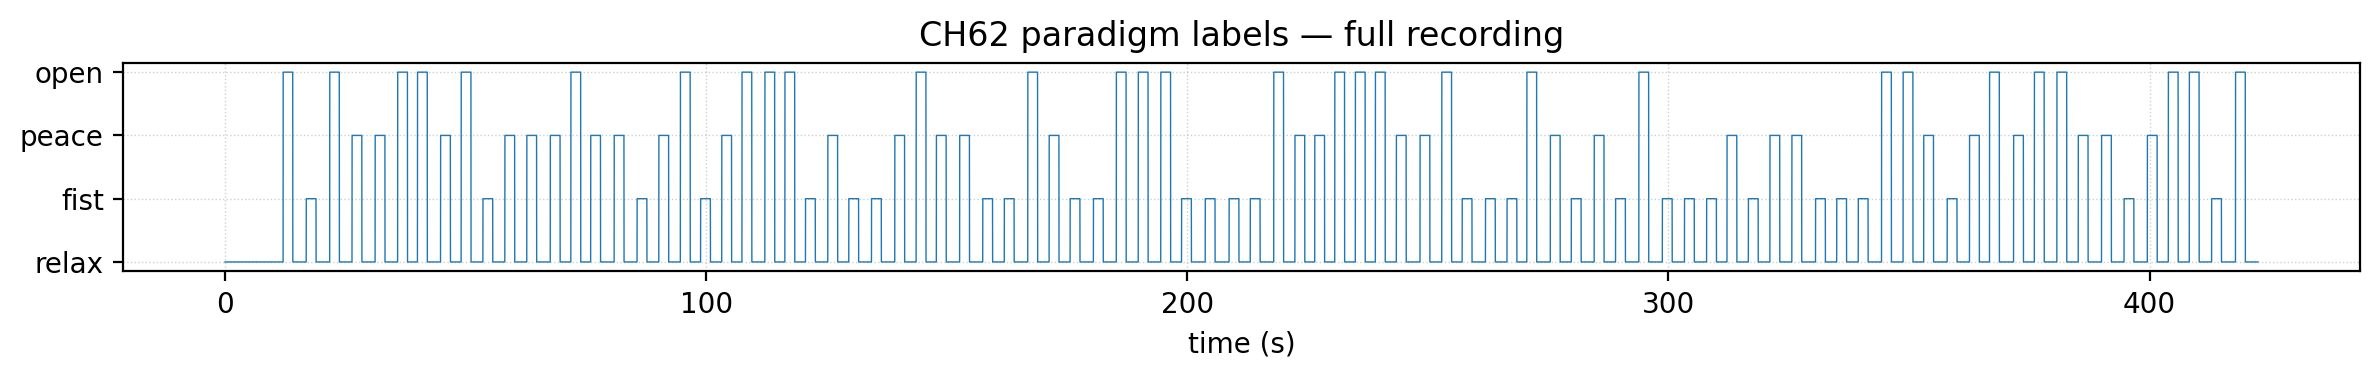

In [ ]:
#| eval: false
fig, ax = plt.subplots(figsize=(12, 2))
ax.plot(rec.time, rec.labels, lw=0.5)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([GESTURE_NAMES[i] for i in [0, 1, 2, 3]])
ax.set_xlabel('time (s)')
ax.set_title('CH62 paradigm labels — full recording')
plt.tight_layout(); plt.show()

## Trial counts per class

Cue onsets are samples where the label transitions `0 → {1, 2, 3}`. Counting by class verifies the documented 90-trial paradigm and surfaces any class imbalance.

 fist: 30 trials
peace: 30 trials
 open: 30 trials
total: 90 trials


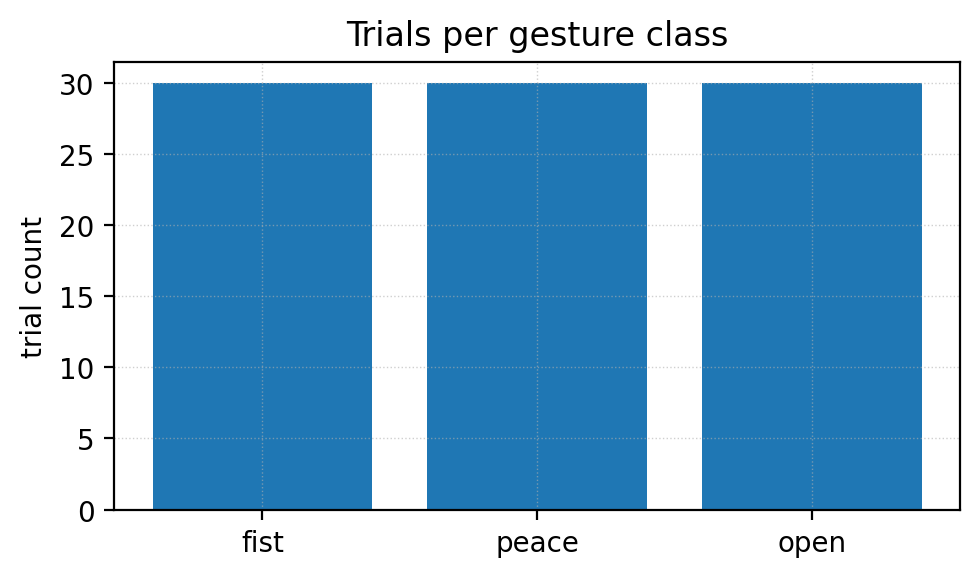

In [ ]:
#| eval: false
labels = rec.labels
onsets = np.where((labels[1:] != 0) & (labels[:-1] == 0))[0] + 1
classes_at_onset = labels[onsets]
uniq, counts = np.unique(classes_at_onset, return_counts=True)
for c, n in zip(uniq, counts):
    print(f'{GESTURE_NAMES[c]:>5}: {n} trials')
print(f'total: {len(onsets)} trials')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([GESTURE_NAMES[c] for c in uniq], counts)
ax.set_ylabel('trial count')
ax.set_title('Trials per gesture class')
plt.tight_layout(); plt.show()

## Per-channel signal stats

Per-channel mean and std flag dead channels (std ≈ 0), saturated channels (std orders of magnitude above the rest), and DC drift (large mean offsets — expected here since the data is DC-coupled, but extreme values still indicate a problem).

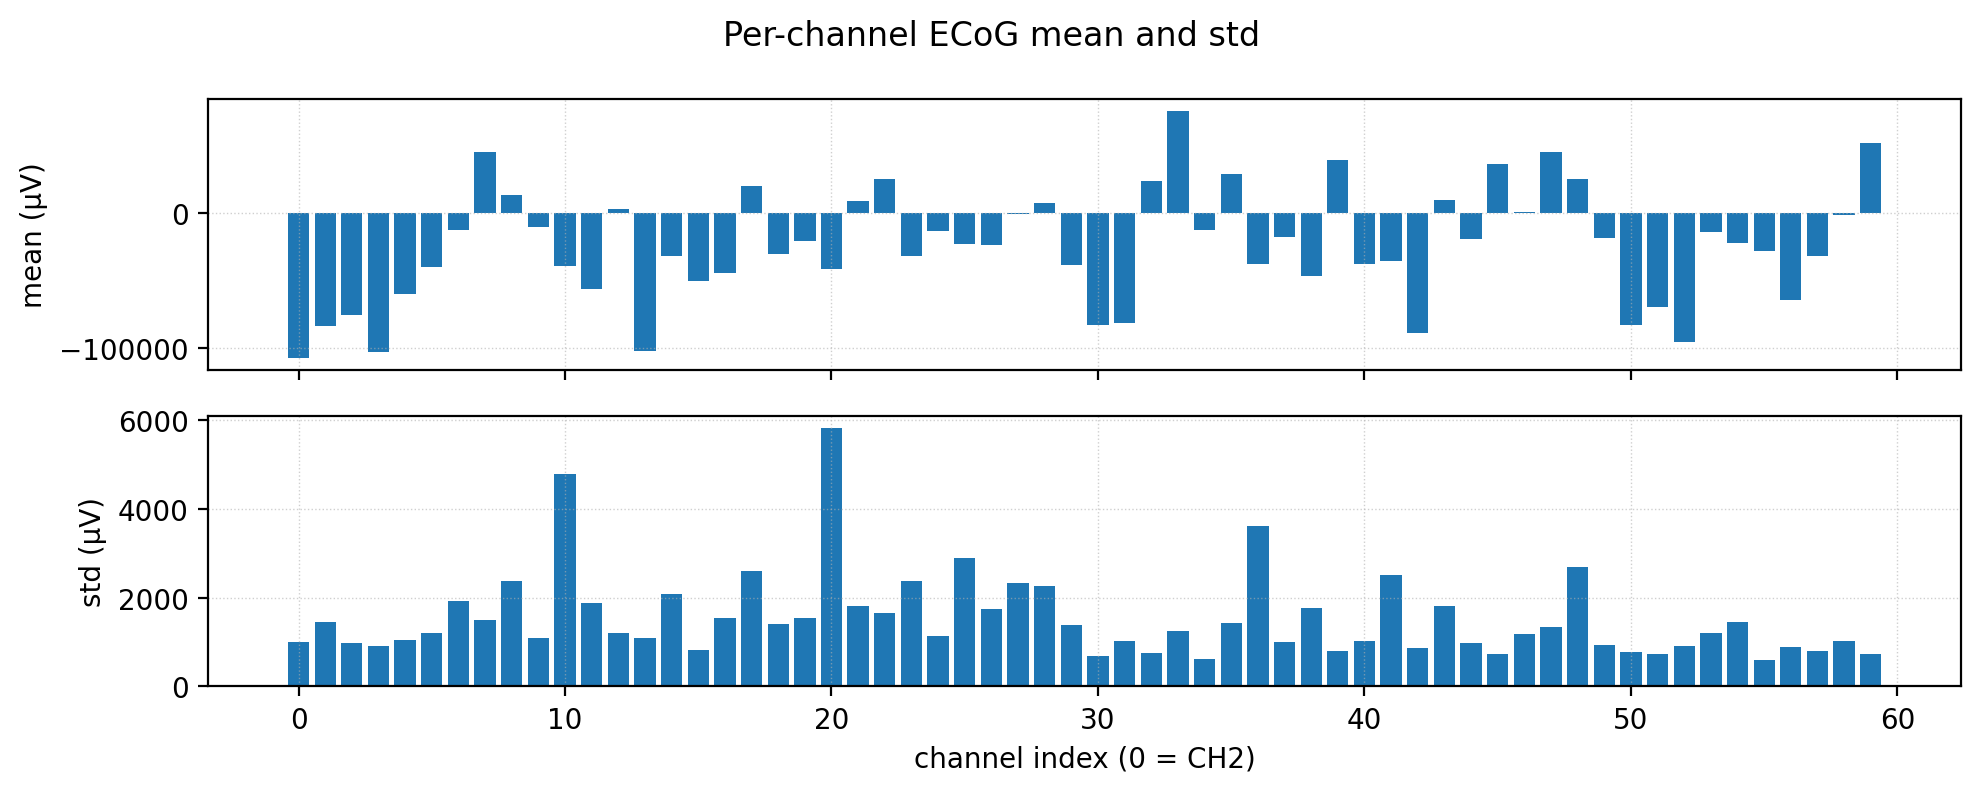

In [ ]:
#| eval: false
mean = rec.ecog.mean(axis=1)
std  = rec.ecog.std(axis=1)
fig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axs[0].bar(np.arange(60), mean); axs[0].set_ylabel('mean (\u03bcV)')
axs[1].bar(np.arange(60), std);  axs[1].set_ylabel('std (\u03bcV)')
axs[1].set_xlabel('channel index (0 = CH2)')
fig.suptitle('Per-channel ECoG mean and std')
plt.tight_layout(); plt.show()

## Spectral overview (PSD)

Welch PSD per channel, overlaid. Two things to look for: line-noise peaks (50 or 60 Hz plus harmonics — informs the notch filter in `03_preprocessing`), and channels whose spectrum is very different from the rest (candidates for rejection).

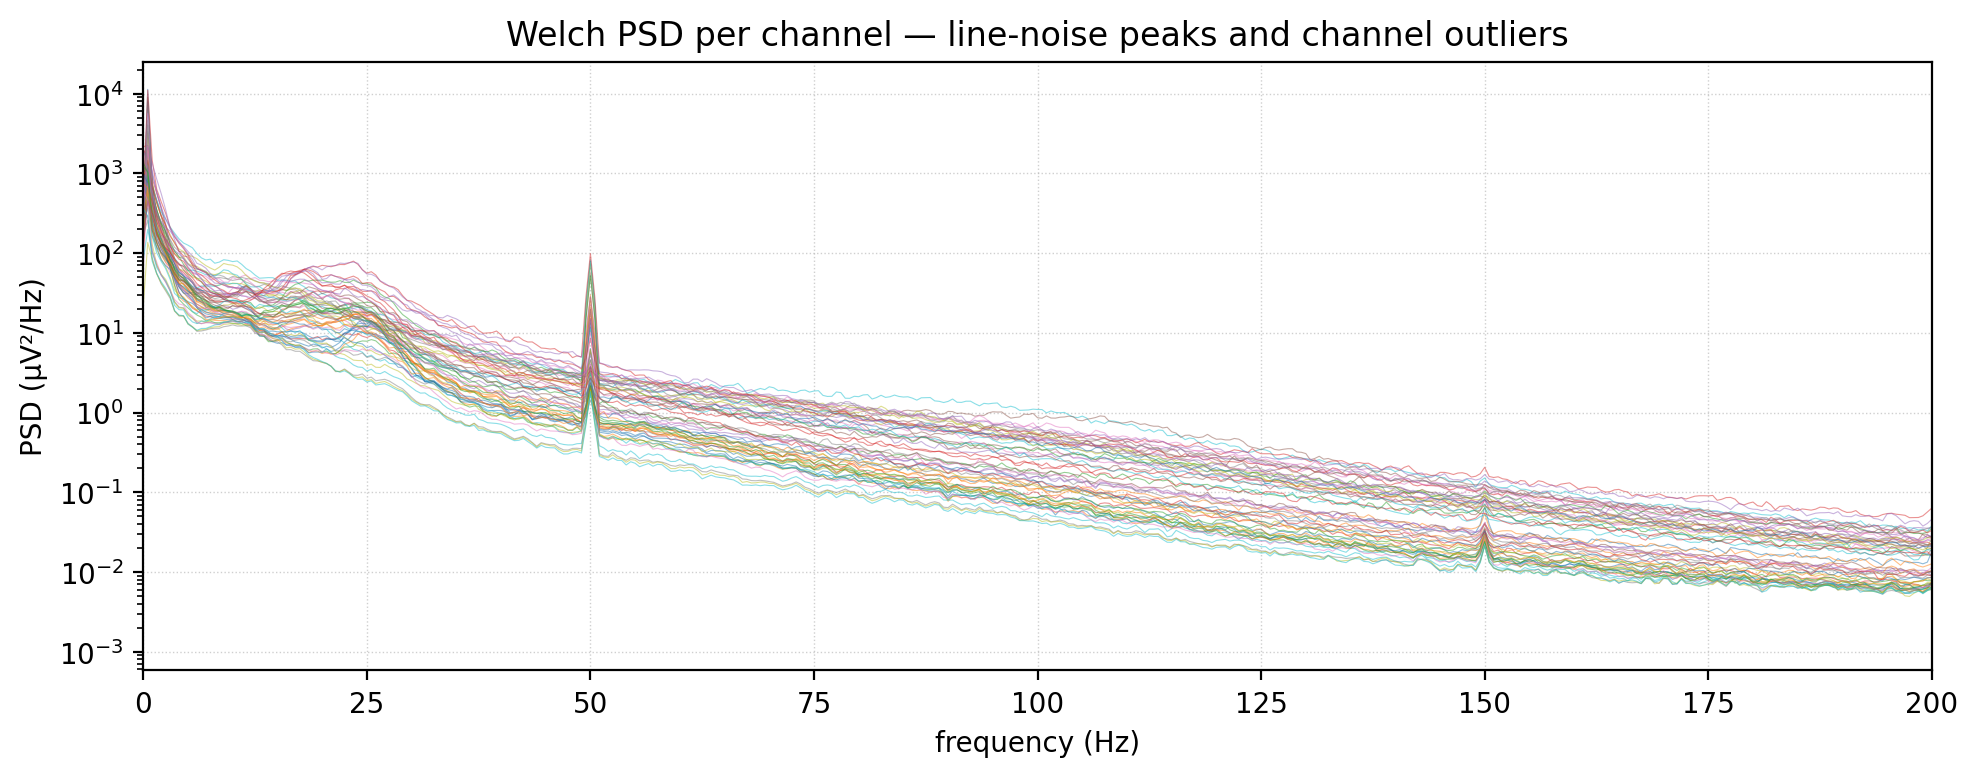

In [ ]:
#| eval: false
freqs, psd = welch(rec.ecog, fs=rec.fs, nperseg=2 * rec.fs)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(freqs, psd.T, lw=0.4, alpha=0.5)
ax.set_xlim(0, 200)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel('PSD (\u03bcV\u00b2/Hz)')
ax.set_title('Welch PSD per channel — line-noise peaks and channel outliers')
plt.tight_layout(); plt.show()

## Glove traces per class

Average finger flexion in a 5 s window after each cue onset, per gesture class. The three gestures should produce visibly distinct finger-flexion patterns (e.g. all fingers flexed for `fist`, only index+middle extended for `peace`). If the patterns aren't separable here, no decoder is going to help.

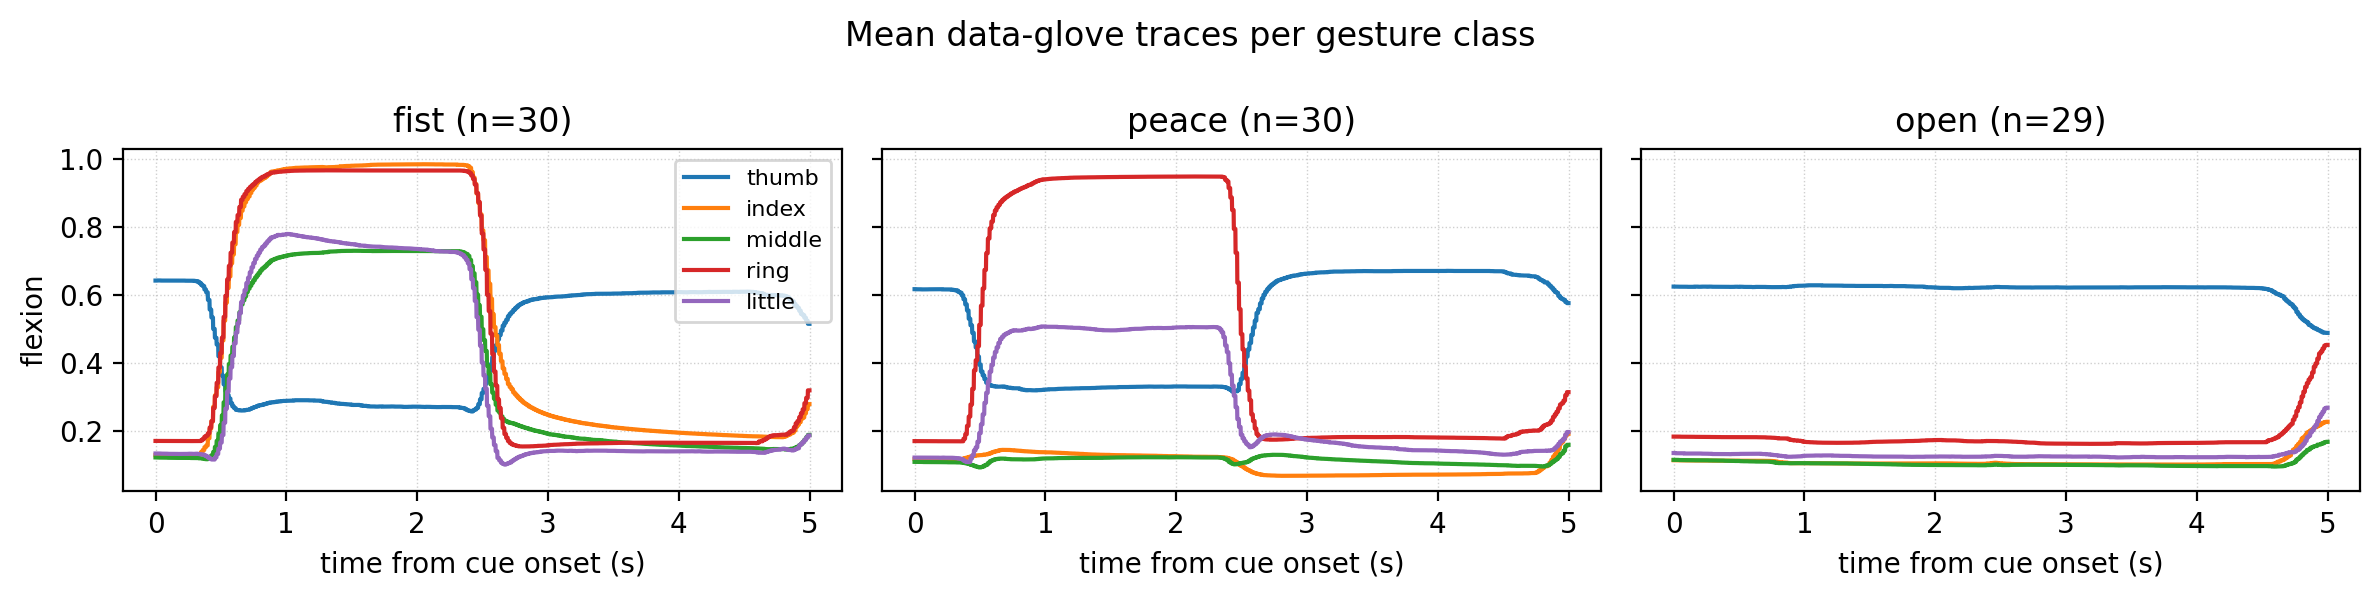

In [ ]:
#| eval: false
window_s = 5
n_win = int(window_s * rec.fs)
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, c in zip(axs, [1, 2, 3]):
    trials = onsets[classes_at_onset == c]
    trials = trials[trials + n_win <= rec.glove.shape[1]]
    snippets = np.stack([rec.glove[:, o:o + n_win] for o in trials])
    mean_trace = snippets.mean(axis=0)
    t_win = np.arange(n_win) / rec.fs
    for fi, fname in enumerate(FINGER_NAMES):
        ax.plot(t_win, mean_trace[fi], label=fname)
    ax.set_title(f'{GESTURE_NAMES[c]} (n={len(trials)})')
    ax.set_xlabel('time from cue onset (s)')
axs[0].set_ylabel('flexion')
axs[0].legend(fontsize=8, loc='best')
fig.suptitle('Mean data-glove traces per gesture class')
plt.tight_layout(); plt.show()

In [ ]:
print('Hello, world!')

Hello, world!
